In [1]:
!pip install -q kagglehub

In [2]:
import kagglehub
dataset_path = kagglehub.dataset_download("nibinv23/iam-handwriting-word-database")

Using Colab cache for faster access to the 'iam-handwriting-word-database' dataset.


In [3]:
import os
import glob
WORDS_TXT = glob.glob(os.path.join(dataset_path, "**", "words*.txt"), recursive=True)[0]
IAM_WORDS = glob.glob(os.path.join(dataset_path, "**", "words"), recursive=True)[0]

In [4]:
WORDS_TXT

'/kaggle/input/iam-handwriting-word-database/words_new.txt'

In [6]:
IAM_WORDS

'/kaggle/input/iam-handwriting-word-database/iam_words/words'

In [25]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import random

In [8]:
IMG_WIDTH = 128
IMG_HEIGHT = 32
BATCH_SIZE = 64

words = []
labels = []
with open(WORDS_TXT, 'r') as f:
    for line in f:
        if line.startswith('#'):
            continue
        splits = line.strip().split(' ')
        if len(splits) < 9 or splits[1] == 'err':
            continue
        word_id = splits[0]
        label = ' '.join(splits[8:])
        parts = word_id.split('-')
        img_path = os.path.join(IAM_WORDS, parts[0], f"{parts[0]}-{parts[1]}", f"{word_id}.png")
        if not os.path.exists(img_path) or os.path.getsize(img_path) < 100:
            continue
        words.append(img_path)
        labels.append(label)

In [9]:
characters = sorted(set(char for label in labels for char in label))
max_length = max(len(label) for label in labels)

In [10]:
char_to_num = layers.StringLookup(vocabulary=list(characters), mask_token=None)
num_to_char = layers.StringLookup(vocabulary=char_to_num.get_vocabulary(), mask_token=None, invert=True)
vocab_size = len(char_to_num.get_vocabulary())

In [20]:
def preprocess_image(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
    img = tf.transpose(img, perm=[1, 0, 2])
    return img

In [21]:
def encode_label(label):
    label = tf.strings.unicode_split(label, input_encoding="UTF-8")
    label = char_to_num(label)
    length = tf.shape(label)[0]
    label = tf.pad(label, paddings=[[0, max_length - length]], constant_values=0)
    return label, length

In [22]:
def augment_image(img):
    img = tf.image.random_brightness(img, max_delta=0.15)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    img = img + tf.random.normal(shape=tf.shape(img), mean=0.0, stddev=0.04)
    shear = tf.random.uniform([], -0.15, 0.15)
    transform = [1.0, shear, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]
    img = tf.squeeze(tf.raw_ops.ImageProjectiveTransformV3(
        images=tf.expand_dims(img, 0), transforms=[transform],
        output_shape=tf.shape(img)[:2], interpolation="BILINEAR",
        fill_mode="CONSTANT", fill_value=1.0), 0)
    img = tf.cond(tf.random.uniform([]) > 0.5,
        lambda: tf.squeeze(tf.nn.avg_pool2d(tf.expand_dims(img, 0), ksize=2, strides=1, padding="SAME"), 0),
        lambda: img)
    return tf.clip_by_value(img, 0.0, 1.0)

In [23]:
def process_train(img_path, label):
    img = augment_image(preprocess_image(img_path))
    enc, ln = encode_label(label)
    return {"image": img, "label": enc, "label_length": ln}

def process_val(img_path, label):
    img = preprocess_image(img_path)
    enc, ln = encode_label(label)
    return {"image": img, "label": enc, "label_length": ln}

In [26]:
combined = list(zip(words, labels))
random.seed(42)
random.shuffle(combined)
words_s, labels_s = zip(*combined)
split = int(0.9 * len(words_s))
train_words, train_labels = words_s[:split], labels_s[:split]
val_words, val_labels = words_s[split:], labels_s[split:]

In [27]:
def make_dataset(image_paths, text_labels, is_training):
    ds = tf.data.Dataset.from_tensor_slices((list(image_paths), list(text_labels)))
    if is_training:
        ds = ds.map(process_train, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.shuffle(2000)
    else:
        ds = ds.map(process_val, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(lambda x: (x, tf.zeros(())))
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

In [28]:
train_ds = make_dataset(train_words, train_labels, True)
val_ds = make_dataset(val_words, val_labels, False)

In [29]:
class CTCLayer(layers.Layer):
    def call(self, y_true, y_pred, label_lengths):
        batch_len = tf.cast(tf.shape(y_true)[0], "int64")
        input_length = tf.cast(tf.shape(y_pred)[1], "int64") * tf.ones((batch_len, 1), dtype="int64")
        label_length = tf.cast(tf.reshape(label_lengths, (-1, 1)), "int64")
        self.add_loss(tf.keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length))
        return y_pred

In [30]:
input_img = layers.Input(shape=(IMG_WIDTH, IMG_HEIGHT, 1), name="image", dtype="float32")
labels_in = layers.Input(name="label", shape=(None,), dtype="float32")
length_in = layers.Input(name="label_length", shape=(1,), dtype="int32")
x = layers.Conv2D(32, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(input_img)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(64, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Reshape(((IMG_WIDTH//4), (IMG_HEIGHT//4)*64))(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)
x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.25))(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.25))(x)
x = layers.Dense(vocab_size + 1, activation="softmax", name="dense2")(x)
output = CTCLayer(name="ctc_loss")(labels_in, x, length_in)

In [31]:
model = tf.keras.models.Model(inputs=[input_img, labels_in, length_in], outputs=output)
model.compile(optimizer=tf.keras.optimizers.Adam(clipnorm=1.0))

In [32]:
EPOCHS = 50

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]
)

Epoch 1/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 84s 132ms/step - loss: 980.1368 - val_loss: 840.6963
Epoch 2/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 73s 129ms/step - loss: 833.7437 - val_loss: 762.1813
Epoch 3/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 67s 119ms/step - loss: 766.1638 - val_loss: 684.8007
Epoch 4/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 83s 120ms/step - loss: 708.2906 - val_loss: 634.9218
Epoch 5/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 66s 118ms/step - loss: 667.1542 - val_loss: 597.1980
Epoch 6/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 66s 118ms/step - loss: 633.0637 - val_loss: 557.6633
Epoch 7/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 81s 116ms/step - loss: 602.8281 - val_loss: 519.0055
Epoch 8/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 66s 118ms/step - loss: 570.3822 - val_loss: 480.2648
Epoch 9/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 64s 115ms/step - loss: 539.6644 - val_loss: 439.4442
Epoch 10/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 64s 115ms/step - loss: 511.3082 - val_loss: 401.4659
Epoch 11/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 65s 116ms/step - loss: 482.7

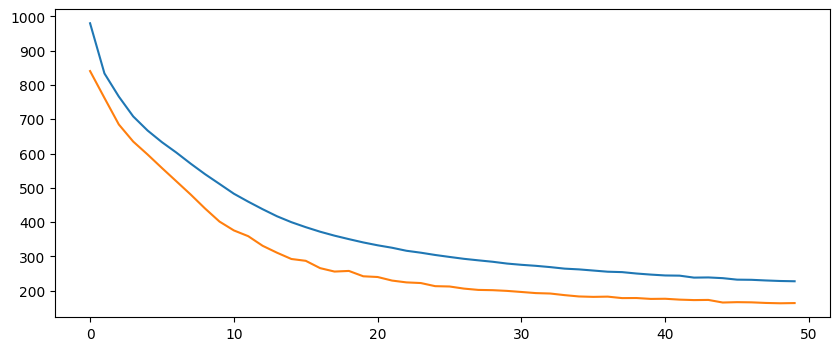

In [33]:
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.show()

In [34]:
prediction_model = tf.keras.models.Model(inputs=model.input[0], outputs=model.get_layer("dense2").output)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step 


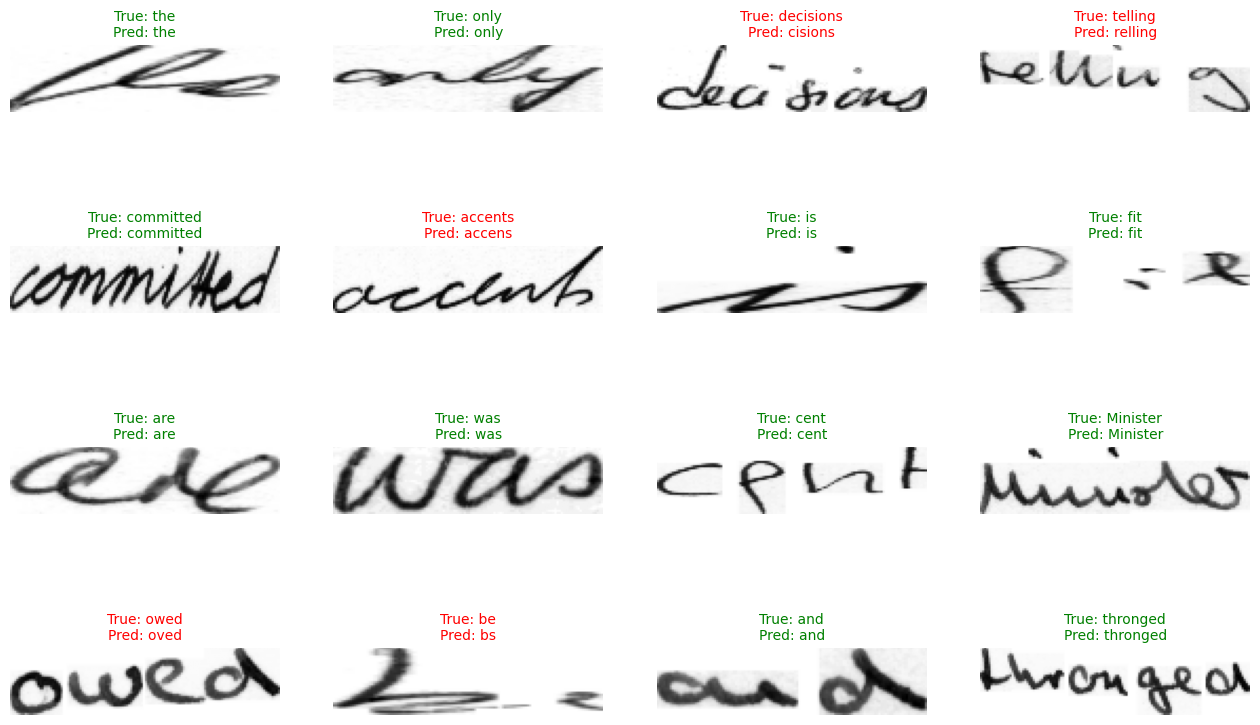

In [35]:
for batch in val_ds.take(1):
    batch_images = batch[0]["image"]
    batch_labels = batch[0]["label"]
    preds = prediction_model.predict(batch_images)
    input_len = np.ones(preds.shape[0]) * preds.shape[1]
    decoded = tf.keras.backend.ctc_decode(preds, input_length=input_len, greedy=True)[0][0][:, :max_length]
    n = min(16, len(decoded))
    fig, axes = plt.subplots(4, 4, figsize=(16, 10))
    for i in range(n):
        raw = tf.strings.reduce_join(num_to_char(decoded[i])).numpy().decode("utf-8").replace("[UNK]", "").strip()
        true = tf.strings.reduce_join(num_to_char(batch_labels[i])).numpy().decode("utf-8").replace("[UNK]", "").strip()
        img = (batch_images[i].numpy() * 255).astype(np.uint8)[:, :, 0].T
        ax = axes[i // 4, i % 4]
        ax.imshow(img, cmap="gray")
        color = "green" if raw.lower() == true.lower() else "red"
        ax.set_title(f"True: {true}\nPred: {raw}", fontsize=10, color=color)
        ax.axis("off")
    plt.show()